# What actually decides an EV purchase

**Playground Series S6E9 — an analysis, not a leaderboard attempt.**

This notebook asks the question a carmaker would ask instead of the one the
leaderboard asks: *which customers buy an electric vehicle, what actually moves
that decision, and who is worth spending money to reach?*

Three things here are worth your time even if you only care about the score:

1. **Gender is significant at p = 0.000000067 and completely useless.** With
   668,665 rows a significance test flags almost anything. Every table below
   reports an effect size next to the p-value.
2. **The subsidy × environmental-concern interaction looks obvious in a
   cross-tab and does not exist.** A likelihood ratio test says p = 0.62. This
   overturned my first conclusion, and it changes the business recommendation.
3. **Logistic regression lands within 0.003 AUC of gradient boosting**, so the
   model worth shipping is the one you can explain.

---

# Điều gì thực sự quyết định việc mua xe điện

**Bài phân tích, không phải bài leo bảng xếp hạng.**

Notebook này đặt câu hỏi của một hãng xe thay vì câu hỏi của bảng xếp hạng:
*ai mua xe điện, điều gì thực sự tác động tới quyết định đó, và nên chi tiền
tiếp cận nhóm nào?*

Ba điểm đáng đọc kể cả khi bạn chỉ quan tâm tới điểm số:

1. **Giới tính có p = 0,000000067 và hoàn toàn vô dụng.** Với 668.665 dòng,
   kiểm định ý nghĩa gắn nhãn "có ý nghĩa" cho gần như mọi thứ. Mọi bảng dưới
   đây đều kèm kích thước hiệu ứng bên cạnh p-value.
2. **Tương tác giữa trợ cấp và mức quan tâm môi trường trông rất rõ trong bảng
   chéo nhưng không hề tồn tại.** Kiểm định tỷ số hợp lý cho p = 0,62. Điều này
   lật ngược kết luận đầu tiên của tôi và thay đổi cả khuyến nghị kinh doanh.
3. **Hồi quy logistic chỉ kém gradient boosting 0,003 AUC**, nên mô hình đáng
   triển khai là mô hình giải thích được.

In [1]:
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

# Works both on Kaggle and on a local checkout. Searched rather than hard-coded,
# because the mount path under /kaggle/input depends on how the data was attached.
KAGGLE_INPUT = Path("/kaggle/input")
if KAGGLE_INPUT.exists():
    print("attached inputs:", [p.name for p in KAGGLE_INPUT.iterdir()] or "(none)")

CANDIDATES = sorted(KAGGLE_INPUT.rglob("train.csv")) if KAGGLE_INPUT.exists() else []
CANDIDATES += [Path("data/train.csv"), Path("../data/train.csv")]
TRAIN = next((p for p in CANDIDATES if p.exists()), None)
if TRAIN is None:
    raise FileNotFoundError(
        "train.csv not found. On Kaggle: open the notebook editor, then "
        "Add Input -> Competitions -> Playground Series S6E9.")
print("reading:", TRAIN)

df = pd.read_csv(TRAIN)
df["will_buy"] = (df["Will_Buy_EV"] == "Yes").astype(int)

TARGET = "will_buy"
NUMERIC = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
           "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
           "Environmental_Concern_Level"]
CATEGORICAL = ["Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible",
               "Subsidy_Available", "Range_Anxiety_Level"]

print(f"{len(df):,} rows x {df.shape[1] - 1} columns")
print(f"missing values: {int(df.isna().sum().sum())}")
print(f"purchase rate: {100 * df[TARGET].mean():.2f}%  "
      f"({df[TARGET].sum():,} buyers / {len(df) - df[TARGET].sum():,} non-buyers)")

reading: ../data/train.csv


668,665 rows x 15 columns
missing values: 0
purchase rate: 17.46%  (116,779 buyers / 551,886 non-buyers)


## 1. Rates need intervals, not just percentages

**EN** — A rate quoted bare invites the reader to treat 19.34% and 18.09% as
different when the counts may not support it. Every rate below carries a Wilson
score interval, which stays inside [0, 1] even for the tiny, lopsided groups in
this data — the high range-anxiety group buys at 0.14% on 2,194 rows, and a
normal approximation would put part of its interval below zero.

**VI** — Một tỷ lệ nêu trần khiến người đọc coi 19,34% và 18,09% là khác nhau
trong khi số lượng quan sát có thể không đủ để kết luận. Mọi tỷ lệ dưới đây đều
kèm khoảng tin cậy Wilson, vốn luôn nằm trong [0, 1] kể cả với những nhóm rất
nhỏ và lệch của bộ dữ liệu này — nhóm lo ngại quãng đường cao mua ở tỷ lệ 0,14%
trên 2.194 dòng, và xấp xỉ chuẩn thông thường sẽ đẩy một phần khoảng tin cậy
xuống dưới 0.

In [2]:
Z = 1.959963984540054

def wilson(successes, total, z=Z):
    """Wilson score interval for a binomial proportion."""
    successes = np.asarray(successes, float)
    total = np.asarray(total, float)
    phat = successes / total
    denom = 1 + z**2 / total
    centre = phat + z**2 / (2 * total)
    spread = z * np.sqrt(phat * (1 - phat) / total + z**2 / (4 * total**2))
    return np.clip((centre - spread) / denom, 0, 1), np.clip((centre + spread) / denom, 0, 1)


def rate_by(frame, column):
    g = frame.groupby(column, observed=True)[TARGET].agg(["size", "sum"])
    g.columns = ["n", "buyers"]
    low, high = wilson(g["buyers"], g["n"])
    g["rate_pct"] = (100 * g["buyers"] / g["n"]).round(2)
    g["ci_low"] = (100 * low).round(2)
    g["ci_high"] = (100 * high).round(2)
    g["lift"] = (g["buyers"] / g["n"] / frame[TARGET].mean()).round(2)
    return g.sort_values("rate_pct", ascending=False).reset_index()

rate_by(df, "Subsidy_Available")

,Subsidy_Available,n,buyers,rate_pct,ci_low,ci_high,lift
0,Yes,419909,115347,27.47,27.33,27.60,1.57
1,No,248756,1432,0.58,0.55,0.61,0.03


## 2. Significance is not importance

**EN** — Cramér's V measures how strongly two categorical variables are
associated, on a 0–1 scale that does not grow with sample size. Put it beside
the p-value and the table sorts itself out: four variables matter and four are
noise that a large sample has made "significant".

Gender reaches p = 6.7e-08 and separates buyers by half a percentage point.
Reporting the p-value alone is how an analysis ends up recommending a
gender-targeted campaign worth nothing.

**VI** — Cramér's V đo độ mạnh của mối liên hệ giữa hai biến phân loại, trên
thang 0–1 và không tăng theo cỡ mẫu. Đặt nó cạnh p-value là bảng tự phân loại:
bốn biến thực sự quan trọng, bốn biến còn lại là nhiễu mà cỡ mẫu lớn đã gắn cho
nhãn "có ý nghĩa".

Giới tính đạt p = 6,7e-08 và chênh lệch giữa các nhóm chỉ nửa điểm phần trăm.
Chỉ báo cáo p-value là cách một bài phân tích đi tới chỗ đề xuất chiến dịch nhắm
theo giới tính — một chiến dịch không đem lại gì.

In [3]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))


rows = []
for column in CATEGORICAL + ["Environmental_Concern_Level", "Number_of_Cars_Owned"]:
    table = pd.crosstab(df[column], df[TARGET]).to_numpy()
    chi2, p, dof, _ = stats.chi2_contingency(table, correction=False)
    levels = rate_by(df, column)
    rows.append({
        "feature": column,
        "cramers_v": round(cramers_v(table), 4),
        "p_value": f"{p:.2e}",
        "spread_pp": round(levels["rate_pct"].max() - levels["rate_pct"].min(), 2),
    })

associations = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
associations["verdict"] = pd.cut(
    associations["cramers_v"], [-0.01, 0.05, 0.10, 0.20, 0.30, 1.0],
    labels=["negligible", "weak", "moderate", "strong", "very strong"])
associations.reset_index(drop=True)

,feature,cramers_v,p_value,spread_pp,verdict
0,Environmental_Concern_Level,0.4966,0.00e+00,51.26,very strong
1,Subsidy_Available,0.3424,0.00e+00,26.89,very strong
2,Range_Anxiety_Level,0.1159,0.00e+00,18.76,moderate
3,Home_Charging_Possible,0.0836,0.00e+00,6.87,weak
4,City_Type,0.0333,4.97e-162,3.23,negligible
5,Current_Car_Type,0.0161,2.06e-37,2.46,negligible
6,Number_of_Cars_Owned,0.0091,6.44e-12,1.25,negligible
7,Gender,0.0070,6.69e-08,0.53,negligible


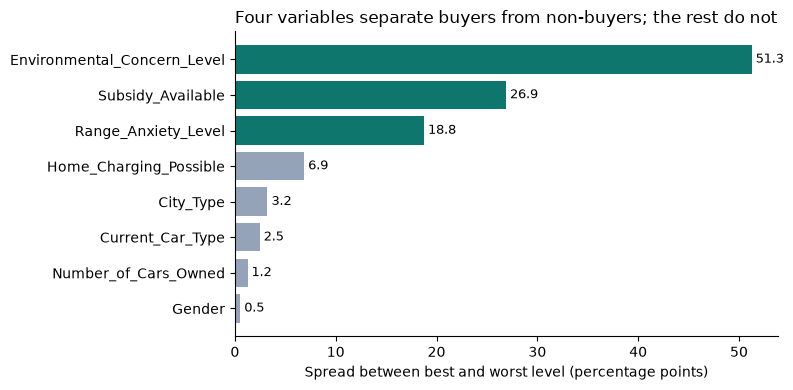

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
data = associations.sort_values("spread_pp")
colours = ["#0f766e" if v > 10 else "#94a3b8" for v in data["spread_pp"]]
ax.barh(data["feature"], data["spread_pp"], color=colours)
for i, v in enumerate(data["spread_pp"]):
    ax.text(v, i, f" {v:.1f}", va="center", fontsize=9)
ax.set_xlabel("Spread between best and worst level (percentage points)")
ax.set_title("Four variables separate buyers from non-buyers; the rest do not",
             loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. The interaction that isn't

**EN** — Here is the cross-tab that made me draw the wrong conclusion first.
Among the most environmentally concerned customers, **69.3% buy with a subsidy
and 2.5% buy without one**. The obvious reading is that the subsidy multiplies
the effect of everything else — that it is a gate rather than a factor.

Test it before believing it.

**VI** — Đây là bảng chéo đã khiến tôi rút ra kết luận sai lúc đầu. Trong nhóm
quan tâm môi trường cao nhất, **69,3% mua khi có trợ cấp và 2,5% mua khi không
có**. Cách đọc hiển nhiên là trợ cấp nhân lên tác dụng của mọi yếu tố khác — nó
là cánh cổng chứ không phải một yếu tố.

Hãy kiểm định trước khi tin.

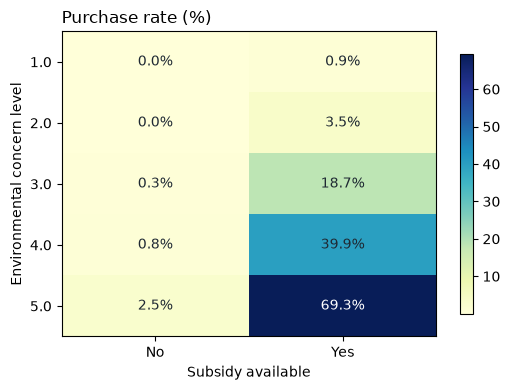

In [5]:
interaction = df.pivot_table(index="Environmental_Concern_Level",
                             columns="Subsidy_Available",
                             values=TARGET, aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(interaction.to_numpy(), cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(interaction.shape[1]), interaction.columns)
ax.set_yticks(range(interaction.shape[0]), interaction.index)
for i in range(interaction.shape[0]):
    for j in range(interaction.shape[1]):
        v = interaction.iloc[i, j]
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center",
                color="white" if v > 40 else "#1f2933")
ax.set_xlabel("Subsidy available")
ax.set_ylabel("Environmental concern level")
ax.set_title("Purchase rate (%)", loc="left")
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

In [6]:
import statsmodels.api as sm

BASE = ["Subsidy_Available", "Environmental_Concern_Level",
        "Range_Anxiety_Level", "Home_Charging_Possible"]
y = df[TARGET].to_numpy()

def design(frame, terms):
    return sm.add_constant(
        pd.get_dummies(frame[terms].astype(str), drop_first=True).astype(float),
        has_constant="add")

reduced_X = design(df, BASE)
reduced = sm.Logit(y, reduced_X).fit(disp=0)

with_term = df.assign(_inter=df["Subsidy_Available"].astype(str) + " x "
                             + df["Environmental_Concern_Level"].astype(str))
full_X = design(with_term, BASE + ["_inter"])
full = sm.Logit(y, full_X).fit(disp=0)

lr = 2 * (full.llf - reduced.llf)
dof = full_X.shape[1] - reduced_X.shape[1]
null_ll = sm.Logit(y, np.ones((len(y), 1))).fit(disp=0).llf

print("Likelihood ratio test: does the interaction earn its parameters?")
print(f"  LR statistic          {lr:.1f} on {dof} df")
print(f"  p-value               {stats.chi2.sf(lr, dof):.3f}")
print(f"  pseudo-R2 without     {1 - reduced.llf / null_ll:.4f}")
print(f"  pseudo-R2 with        {1 - full.llf / null_ll:.4f}")

Likelihood ratio test: does the interaction earn its parameters?
  LR statistic          7.2 on 9 df
  p-value               0.616
  pseudo-R2 without     0.4574
  pseudo-R2 with        0.4574


**EN** — p = 0.62, and McFadden's pseudo-R² does not move. The interaction term
buys nothing. So why does the cross-tab look so dramatic?

Because logistic regression is multiplicative **on the odds scale**, while the
cross-tab is on the **probability scale**. Multiply odds of 0.1% by thirty and
you are still near zero; multiply odds of 30% by thirty and you hit the ceiling.
Independent effects produce exactly that picture when one group starts near zero.

The check below settles it: a model with **main effects only** reproduces every
cell of that table.

**VI** — p = 0,62 và pseudo-R² McFadden không nhúc nhích. Số hạng tương tác
không mang lại gì. Vậy tại sao bảng chéo trông kịch tính đến thế?

Vì hồi quy logistic nhân tính **trên thang odds**, còn bảng chéo nằm trên thang
**xác suất**. Nhân odds 0,1% với ba mươi thì vẫn gần 0; nhân odds 30% với ba
mươi thì chạm trần. Các hiệu ứng độc lập tạo ra đúng bức tranh đó khi một nhóm
xuất phát từ gần 0.

Phép kiểm chứng dưới đây khẳng định điều đó: mô hình **chỉ có hiệu ứng chính**
tái tạo được mọi ô của bảng.

In [7]:
df["predicted"] = reduced.predict(reduced_X)
observed = df.pivot_table(index="Environmental_Concern_Level",
                          columns="Subsidy_Available", values=TARGET, aggfunc="mean") * 100
predicted = df.pivot_table(index="Environmental_Concern_Level",
                           columns="Subsidy_Available", values="predicted", aggfunc="mean") * 100

comparison = pd.concat({"observed": observed.round(2),
                        "predicted (main effects only)": predicted.round(2),
                        "gap (pp)": (observed - predicted).round(2)}, axis=1)
print("Largest disagreement anywhere in the table: "
      f"{float((observed - predicted).abs().to_numpy().max()):.2f} percentage points")
comparison

Largest disagreement anywhere in the table: 0.12 percentage points


observed        predicted (main effects only)        gap (pp)      
Subsidy_Available                 No    Yes                            No    Yes       No   Yes
Environmental_Concern_Level                                                                    
1.0                             0.02   0.94                          0.01   0.94     0.01 -0.00
2.0                             0.05   3.48                          0.04   3.48     0.01 -0.00
3.0                             0.30  18.66                          0.27  18.68     0.03 -0.02
4.0                             0.81  39.94                          0.78  39.96     0.03 -0.02
5.0                             2.48  69.33                          2.60  69.29    -0.12  0.04

### Why this changes the recommendation

**EN** — "Subsidies unlock environmental preference" and "subsidies and
preference each help, independently" point at different strategies. The first
says target subsidised regions exclusively. The second says a region without a
subsidy still contains high-concern, high-income buyers worth reaching — at a
lower conversion rate, but not at zero.

**VI** — "Trợ cấp mở khóa cho sở thích môi trường" và "trợ cấp và sở thích môi
trường mỗi thứ đều có tác dụng, độc lập nhau" dẫn tới hai chiến lược khác nhau.
Cách hiểu thứ nhất bảo chỉ nhắm vào vùng có trợ cấp. Cách thứ hai nói vùng không
có trợ cấp vẫn chứa những khách quan tâm môi trường, thu nhập cao đáng tiếp cận —
với tỷ lệ chuyển đổi thấp hơn, nhưng không phải bằng không.

## 4. Income is a smooth gradient; charging infrastructure does nothing

**EN** — Income moves the purchase rate by 25 points with no threshold anywhere.
But two of these variables behave in ways a real EV market does not, and that is
worth saying out loud rather than modelling around.

**VI** — Thu nhập làm tỷ lệ mua dịch chuyển 25 điểm mà không có ngưỡng gãy nào.
Nhưng hai biến trong số này hành xử khác hẳn thị trường xe điện thật, và điều đó
nên được nói thẳng thay vì lặng lẽ đưa vào mô hình.

In [8]:
rows = []
for column in ["Annual_Income_USD", "Daily_Commute_km", "Charging_Stations_Near_Home",
               "Age", "Charging_Stations_Near_Work"]:
    binned = df.assign(_bin=pd.qcut(df[column], 6, duplicates="drop"))
    table = binned.groupby("_bin", observed=True)[TARGET].mean() * 100
    rows.append({"feature": column,
                 "lowest_bin_pct": round(table.iloc[0], 2),
                 "highest_bin_pct": round(table.iloc[-1], 2),
                 "spread_pp": round(table.max() - table.min(), 2)})
pd.DataFrame(rows).sort_values("spread_pp", ascending=False).reset_index(drop=True)

,feature,lowest_bin_pct,highest_bin_pct,spread_pp
0,Annual_Income_USD,6.29,31.43,25.15
1,Daily_Commute_km,19.59,14.35,5.24
2,Charging_Stations_Near_Home,19.15,17.21,3.14
3,Age,17.94,16.01,2.68
4,Charging_Stations_Near_Work,18.62,17.07,1.73


**EN** — Charging availability near home is one of the most-cited determinants
of EV adoption in the published literature, and here it moves the rate by three
points — with the *most* stations attached to a slightly *lower* rate. Longer
commutes also reduce purchase probability, where in reality a longer commute
increases the fuel saving that makes an EV pay back.

The `Home_Charging_Possible` flag does behave sensibly (19.6% against 12.7%). So
the generator modelled *whether you can charge at home* but not *how many public
chargers are nearby*. **Anyone using this data to argue about charger rollout
would be arguing from an artefact of the synthetic generator.**

**VI** — Khả năng tiếp cận trạm sạc gần nhà là một trong những yếu tố quyết định
được trích dẫn nhiều nhất trong tài liệu nghiên cứu, còn ở đây nó chỉ làm tỷ lệ
dịch chuyển ba điểm — và nhóm có **nhiều** trạm sạc nhất lại có tỷ lệ hơi
**thấp** hơn. Đi làm xa cũng làm giảm khả năng mua, trong khi thực tế đi càng xa
thì tiền nhiên liệu tiết kiệm được càng lớn.

Biến `Home_Charging_Possible` lại hành xử hợp lý (19,6% so với 12,7%). Nghĩa là
bộ sinh dữ liệu có mô hình hóa *việc bạn có sạc được ở nhà không* nhưng không mô
hình hóa *quanh đó có bao nhiêu trạm sạc công cộng*. **Ai dùng dữ liệu này để
tranh luận về triển khai trạm sạc là đang tranh luận dựa trên một lỗi kỹ thuật
của bộ sinh.**

## 5. Modelling — and why accuracy is not reported

**EN** — 17.5% of rows are buyers, so predicting "nobody buys" scores 82.5%
accuracy and describes a useless model. What is reported instead:

- **ROC-AUC** — ranking quality.
- **Average precision** — area under the precision–recall curve, sensitive to
  the minority class.
- **Brier score** — because the output is used as a probability, and a marketing
  budget is allocated on the number, not on the label.

Scores come from out-of-fold predictions across five folds, so every row is
scored by a model that never saw it.

**VI** — 17,5% số dòng là người mua, nên đoán "không ai mua" đã đạt 82,5% độ
chính xác và mô tả một mô hình vô dụng. Thay vào đó báo cáo:

- **ROC-AUC** — chất lượng xếp hạng.
- **Average precision** — diện tích dưới đường precision–recall, nhạy với nhóm
  thiểu số.
- **Brier score** — vì đầu ra được dùng như một xác suất, và ngân sách marketing
  được phân bổ dựa trên con số đó chứ không phải nhãn.

Điểm số lấy từ dự đoán ngoài lớp huấn luyện qua 5 lớp, nên mọi dòng đều được
chấm bởi mô hình chưa từng nhìn thấy nó.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

features = NUMERIC + CATEGORICAL
X, yv = df[features], df[TARGET].to_numpy()

def make(model):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL)])),
        ("model", model)])

cv = StratifiedKFold(5, shuffle=True, random_state=42)
scores, probabilities = [], {}
for name, model in [("logistic regression", LogisticRegression(max_iter=1000, n_jobs=-1)),
                    ("gradient boosting", HistGradientBoostingClassifier(
                        max_iter=300, learning_rate=0.08, early_stopping=True,
                        validation_fraction=0.1, random_state=42))]:
    p = cross_val_predict(make(model), X, yv, cv=cv, method="predict_proba")[:, 1]
    probabilities[name] = p
    scores.append({"model": name,
                   "roc_auc": round(roc_auc_score(yv, p), 4),
                   "average_precision": round(average_precision_score(yv, p), 4),
                   "brier": round(brier_score_loss(yv, p), 5)})

pd.DataFrame(scores)

,model,roc_auc,average_precision,brier
0,logistic regression,0.9381,0.7411,0.07357
1,gradient boosting,0.9411,0.7533,0.07159


**EN** — Gradient boosting wins by 0.003 AUC. In a business setting that does
not pay for losing the ability to say *why* a customer scored the way they did,
so the logistic model is the one to ship. Its coefficients read as odds ratios —
for the numeric variables, per one standard deviation.

**VI** — Gradient boosting thắng 0,003 AUC. Trong bối cảnh kinh doanh, chênh
lệch đó không đủ để đánh đổi lấy việc mất khả năng giải thích **vì sao** một
khách hàng được chấm điểm như vậy — nên mô hình nên triển khai là hồi quy
logistic. Hệ số của nó đọc thẳng thành tỷ số odds; với biến số là trên mỗi độ
lệch chuẩn.

In [10]:
fitted = make(LogisticRegression(max_iter=1000, n_jobs=-1)).fit(X, yv)
names = fitted.named_steps["prep"].get_feature_names_out()
coefficients = fitted.named_steps["model"].coef_[0]

odds = (pd.DataFrame({"term": [n.split("__", 1)[1] for n in names],
                      "coefficient": coefficients.round(3),
                      "odds_ratio": np.exp(coefficients).round(3)})
        .reindex(np.argsort(-np.abs(coefficients)))
        .head(8).reset_index(drop=True))
odds

,term,coefficient,odds_ratio
0,Subsidy_Available_Yes,4.515,91.376
1,Range_Anxiety_Level_Low,3.377,29.291
2,Environmental_Concern_Level,1.875,6.518
3,Range_Anxiety_Level_Medium,1.748,5.744
4,Annual_Income_USD,0.726,2.067
5,Home_Charging_Possible_Yes,0.231,1.260
6,Current_Car_Type_Truck,-0.094,0.910
7,Daily_Commute_km,-0.086,0.918


## 6. What it is worth: contact the top 30%, reach 92% of buyers

**EN** — This is the form the model's value takes in a marketing plan, and it is
readable by people who will never look at an ROC curve.

**VI** — Đây là hình thức mà giá trị của mô hình thể hiện trong một kế hoạch
marketing, và người chưa từng nhìn đường ROC vẫn đọc được.

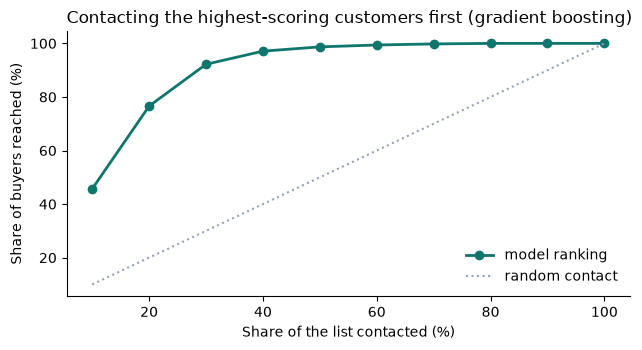

,contact_top_pct,buyers_reached_pct,rate_in_segment_pct,lift_vs_random
0,10,45.7,79.89,4.57
1,20,76.6,66.86,3.83
2,30,92.2,53.66,3.07
3,40,97.1,42.40,2.43
4,50,98.7,34.48,1.97
5,60,99.4,28.94,1.66
6,70,99.8,24.90,1.43
7,80,100.0,21.82,1.25
8,90,100.0,19.40,1.11
9,100,100.0,17.46,1.00


In [11]:
best = max(scores, key=lambda s: s["roc_auc"])["model"]
order = np.argsort(-probabilities[best])
ranked = yv[order]

lift = pd.DataFrame([{
    "contact_top_pct": d * 10,
    "buyers_reached_pct": round(100 * ranked[:int(len(ranked) * d / 10)].sum() / ranked.sum(), 1),
    "rate_in_segment_pct": round(100 * ranked[:int(len(ranked) * d / 10)].mean(), 2),
    "lift_vs_random": round(ranked[:int(len(ranked) * d / 10)].mean() / ranked.mean(), 2),
} for d in range(1, 11)])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(lift["contact_top_pct"], lift["buyers_reached_pct"], marker="o",
        color="#0f766e", linewidth=2, label="model ranking")
ax.plot(lift["contact_top_pct"], lift["contact_top_pct"], linestyle=":",
        color="#94a3b8", label="random contact")
ax.set_xlabel("Share of the list contacted (%)")
ax.set_ylabel("Share of buyers reached (%)")
ax.set_title(f"Contacting the highest-scoring customers first ({best})", loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

lift

## Conclusions

**EN**

1. **Qualify on subsidy eligibility first** — the largest term in the model, and
   knowable before any contact is made. But do not write off unsubsidised
   regions: section 3 shows preference still operates there, at lower rates.
2. **Score the list and cut it at 30%** — reaching 92% of buyers for 30% of the
   contact cost is the clearest operational win here.
3. **Ask about range anxiety early.** An odds ratio of ~29 between low and high
   anxiety, on a question a salesperson can simply ask.
4. **Stop segmenting by gender, car ownership or current car type.** All three
   are statistically significant and commercially worthless.
5. **Do not use this data to plan charger placement.** See section 4.

### Limits

- **The data is synthetic**, generated by Kaggle from a model of a real survey.
  Conclusions hold for *this dataset*; extending them to a real market needs the
  real survey.
- **Observational, not causal.** Subsidy availability is not randomly assigned.
- **A 0.58% base rate without subsidy is implausible** for a real market, where
  some buyers are always indifferent to incentives.
- **No time dimension** — no purchase dates, so nothing about seasonality or
  what happens when a subsidy is introduced or withdrawn.
- **Metrics are cross-validated on the training set**; no leaderboard score is
  claimed here.

**VI**

1. **Sàng lọc theo điều kiện hưởng trợ cấp trước tiên** — số hạng lớn nhất trong
   mô hình và biết được trước khi tiếp cận khách. Nhưng đừng loại bỏ hẳn vùng
   không có trợ cấp: mục 3 cho thấy sở thích môi trường vẫn phát huy tác dụng ở
   đó, chỉ với tỷ lệ thấp hơn.
2. **Chấm điểm danh sách rồi cắt ở mốc 30%** — chạm 92% người mua với 30% chi
   phí tiếp cận là lợi ích vận hành rõ ràng nhất.
3. **Hỏi về lo ngại quãng đường ngay từ đầu.** Tỷ số odds khoảng 29 lần giữa
   nhóm lo ngại thấp và cao, trên một câu hỏi nhân viên bán hàng chỉ cần hỏi miệng.
4. **Ngừng phân khúc theo giới tính, số xe sở hữu hay loại xe đang dùng.** Cả ba
   đều có ý nghĩa thống kê và vô giá trị về mặt thương mại.
5. **Không dùng dữ liệu này để hoạch định vị trí trạm sạc.** Xem mục 4.

### Giới hạn

- **Dữ liệu là tổng hợp**, do Kaggle sinh ra từ mô hình của một khảo sát thật.
  Kết luận đúng cho *bộ dữ liệu này*; muốn suy rộng ra thị trường thật phải dùng
  khảo sát gốc.
- **Quan sát, không phải nhân quả.** Điều kiện hưởng trợ cấp không phân bổ ngẫu nhiên.
- **Tỷ lệ nền 0,58% khi không có trợ cấp là không thực tế** với thị trường thật,
  nơi luôn có người mua bất kể chính sách hỗ trợ.
- **Không có chiều thời gian** — không có ngày mua, nên không nói được gì về tính
  mùa vụ hay điều gì xảy ra khi trợ cấp được ban hành hoặc bị rút.
- **Mọi chỉ số đều từ kiểm định chéo trên tập huấn luyện**; bài này không tuyên
  bố thứ hạng nào trên bảng xếp hạng.

---

*Full source, tests and CI: [github.com/conchocon154/ev-purchase-analysis](https://github.com/conchocon154/ev-purchase-analysis)*